In [ ]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from sklearn.neural_network import MLPClassifier
from sklearn.metrics import accuracy_score, f1_score

In [ ]:
# 1. Cargar el Data-Set
df = pd.read_csv('used_cars.csv')

In [ ]:
# --- LIMPIEZA DE DATOS REALES ---
df['price'] = df['price'].astype(str).str.replace('$', '').str.replace(',', '')
df['price'] = pd.to_numeric(df['price'], errors='coerce')

In [ ]:
df['milage'] = df['milage'].astype(str).str.replace(' mi.', '').str.replace(',', '')
df['milage'] = pd.to_numeric(df['milage'], errors='coerce')

In [ ]:
df['model_year'] = pd.to_numeric(df['model_year'], errors='coerce')

In [ ]:
col_precio = 'price'
cols_categoricas = ['brand', 'model', 'fuel_type', 'transmission']
cols_numericas = ['model_year', 'milage']

In [ ]:
# Eliminar filas que se hayan quedado sin datos esenciales tras la limpieza
df = df.dropna(subset=[col_precio] + cols_categoricas + cols_numericas)

In [ ]:
# Crear las 3 categorías de precio (Económico, Estándar, Premium) usando cuantiles
df['Categoria_Precio'] = pd.qcut(df[col_precio], q=3, labels=['Económico', 'Estándar', 'Premium'])

X = df[cols_categoricas + cols_numericas]
y = df['Categoria_Precio']

In [ ]:
# Crear transformadores para One-Hot Encoding y Estandarización
preprocesador = ColumnTransformer(
    transformers=[
        ('num', StandardScaler(), cols_numericas),
        ('cat', OneHotEncoder(handle_unknown='ignore'), cols_categoricas)
    ])

In [ ]:
# 3. Partición del Data-Set (80% Entrenamiento, 20% Prueba)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.20, random_state=42)

print(f"--- FASE DE PARTICIÓN ---")
print(f"Registros para Entrenamiento (80%): {X_train.shape[0]}")
print(f"Registros para Prueba (20%): {X_test.shape[0]}\n")

--- FASE DE PARTICIÓN ---
Registros para Entrenamiento (80%): 3071
Registros para Prueba (20%): 768



In [ ]:
# 4. Instanciar Modelos en Pipelines
rf_pipeline = Pipeline(steps=[('preprocessor', preprocesador),
                              ('classifier', RandomForestClassifier(n_estimators=100, random_state=42))])

svm_pipeline = Pipeline(steps=[('preprocessor', preprocesador),
                               ('classifier', SVC(random_state=42))])

mlp_pipeline = Pipeline(steps=[('preprocessor', preprocesador),
                               ('classifier', MLPClassifier(hidden_layer_sizes=(100, 50), max_iter=200, random_state=42))])

In [ ]:
# 5. Entrenamiento (Training)
print("Entrenando modelos... (Esto tomará unos segundos por la cantidad de marcas/modelos distintas)")
rf_pipeline.fit(X_train, y_train)
svm_pipeline.fit(X_train, y_train)
mlp_pipeline.fit(X_train, y_train)

Entrenando modelos... (Esto tomará unos segundos por la cantidad de marcas/modelos distintas)


Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('num', StandardScaler(),
                                                  ['model_year', 'milage']),
                                                 ('cat',
                                                  OneHotEncoder(handle_unknown='ignore'),
                                                  ['brand', 'model',
                                                   'fuel_type',
                                                   'transmission'])])),
                ('classifier',
                 MLPClassifier(hidden_layer_sizes=(100, 50), random_state=42))])

In [ ]:
# 6. Prueba y Resultados (Testing)
rf_preds = rf_pipeline.predict(X_test)
svm_preds = svm_pipeline.predict(X_test)
mlp_preds = mlp_pipeline.predict(X_test)

print("\n--- RESULTADOS DE COMPROBACIÓN ---")
print(f"Random Forest -> Exactitud: {accuracy_score(y_test, rf_preds)*100:.2f}% | F1-Score: {f1_score(y_test, rf_preds, average='weighted')*100:.2f}%")
print(f"SVM           -> Exactitud: {accuracy_score(y_test, svm_preds)*100:.2f}% | F1-Score: {f1_score(y_test, svm_preds, average='weighted')*100:.2f}%")
print(f"Red Neuronal  -> Exactitud: {accuracy_score(y_test, mlp_preds)*100:.2f}% | F1-Score: {f1_score(y_test, mlp_preds, average='weighted')*100:.2f}%")


--- RESULTADOS DE COMPROBACIÓN ---
Random Forest -> Exactitud: 77.08% | F1-Score: 76.71%
SVM           -> Exactitud: 79.95% | F1-Score: 79.91%
Red Neuronal  -> Exactitud: 80.60% | F1-Score: 80.64%


In [ ]:
from sklearn.model_selection import cross_val_score

# 4.5 Set de Validación por "Cross-Validation"
print("\n--- FASE DE VALIDACIÓN CRUZADA (K-Fold = 5) ---")

# Aplicando Cross-Validation al Pipeline de Random Forest usando el Set de Entrenamiento
scores_rf = cross_val_score(rf_pipeline, X_train, y_train, cv=5, scoring='accuracy')

print(f"Precisión en cada fold (Random Forest): {scores_rf}")
print(f"Precisión media de validación: {scores_rf.mean():.4f} (+/- {scores_rf.std() * 2:.4f})")


--- FASE DE VALIDACIÓN CRUZADA (K-Fold = 5) ---
Precisión en cada fold (Random Forest): [0.75772358 0.76058632 0.78013029 0.7980456  0.77198697]
Precisión media de validación: 0.7737 (+/- 0.0292)


In [ ]:
# 5.1 Aplicación al Modelo: uso del Data-Set de Entrenamiento y de Prueba
from sklearn.metrics import classification_report

print("\n--- FASE DE COMPROBACIÓN (TESTING) ---")
# Predecir con el subconjunto de pruebas no visto
y_pred_rf = rf_pipeline.predict(X_test)

# Reporte final
print("Reporte de Clasificación (Random Forest):")
print(classification_report(y_test, y_pred_rf))


--- FASE DE COMPROBACIÓN (TESTING) ---
Reporte de Clasificación (Random Forest):
              precision    recall  f1-score   support

   Económico       0.81      0.88      0.84       244
    Estándar       0.67      0.60      0.63       247
     Premium       0.82      0.83      0.82       277

    accuracy                           0.77       768
   macro avg       0.76      0.77      0.77       768
weighted avg       0.77      0.77      0.77       768



In [ ]:
from sklearn.metrics import precision_score, recall_score
import pandas as pd
from IPython.display import display

# Utilizamos las predicciones que ya calculaste arriba para los 3 modelos
def evaluar_modelo(y_true, y_pred, nombre_modelo):
    acc = accuracy_score(y_true, y_pred)
    prec = precision_score(y_true, y_pred, average='weighted')
    rec = recall_score(y_true, y_pred, average='weighted')
    f1 = f1_score(y_true, y_pred, average='weighted')
    return [nombre_modelo, f"{acc*100:.2f}%", f"{prec*100:.2f}%", f"{rec*100:.2f}%", f"{f1*100:.2f}%"]

resultados = [
    evaluar_modelo(y_test, rf_preds, "Random Forest"),
    evaluar_modelo(y_test, svm_preds, "SVM"),
    evaluar_modelo(y_test, mlp_preds, "Red Neuronal (MLP)")
]

df_resultados = pd.DataFrame(resultados, columns=["Modelo", "Exactitud", "Precisión", "Sensibilidad", "F1-Score"])
print("--- MÉTRICAS Y EVALUACIÓN DE LOS MODELOS ---")
display(df_resultados)

--- MÉTRICAS Y EVALUACIÓN DE LOS MODELOS ---


,Modelo,Exactitud,Precisión,Sensibilidad,F1-Score
0,Random Forest,77.08%,76.59%,77.08%,76.71%
1,SVM,79.95%,79.89%,79.95%,79.91%
2,Red Neuronal (MLP),80.60%,80.70%,80.60%,80.64%



--- MATRIZ DE CONFUSIÓN (Modelo: Random Forest) ---


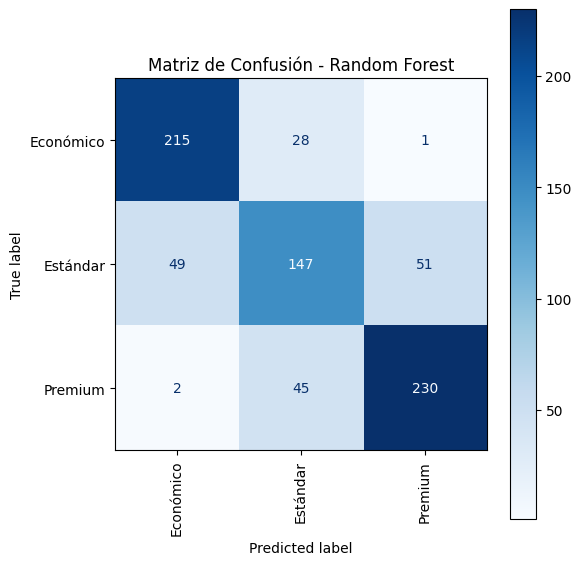

In [ ]:
from sklearn.metrics import ConfusionMatrixDisplay
import matplotlib.pyplot as plt

print("\n--- MATRIZ DE CONFUSIÓN (Modelo: Random Forest) ---")
fig, ax = plt.subplots(figsize=(6, 6))
ConfusionMatrixDisplay.from_predictions(y_test, rf_preds, ax=ax, cmap='Blues', xticks_rotation='vertical')
plt.title('Matriz de Confusión - Random Forest')
plt.tight_layout()
plt.show()


--- EVALUACIÓN DEL SISTEMA: IMPORTANCIA DE CARACTERÍSTICAS ---


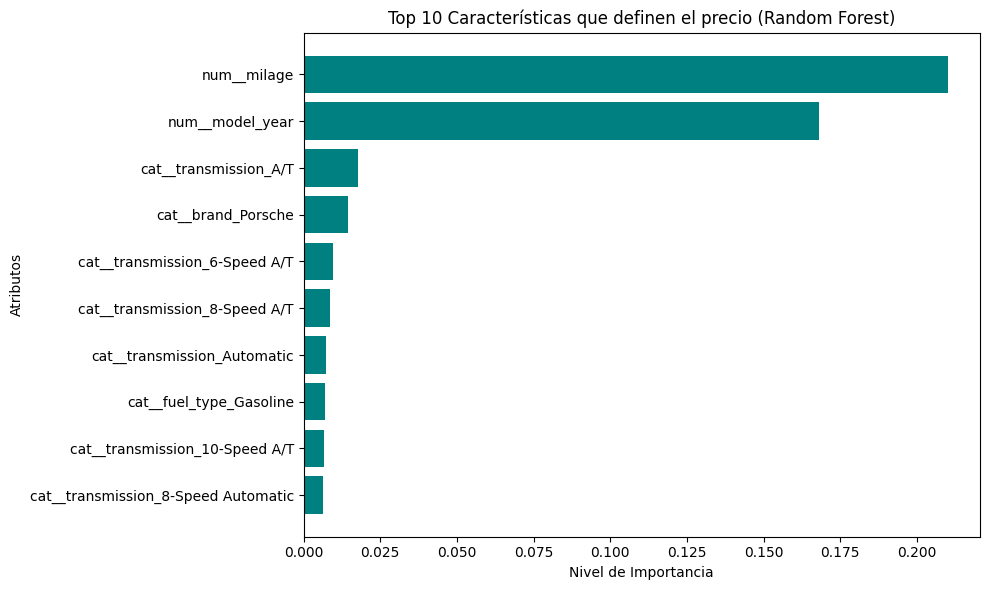

In [ ]:
print("\n--- EVALUACIÓN DEL SISTEMA: IMPORTANCIA DE CARACTERÍSTICAS ---")

# Extraer el modelo y el preprocesador del pipeline
rf_model = rf_pipeline.named_steps['classifier']
preprocesador = rf_pipeline.named_steps['preprocessor']

# Extraer importancias y nombres
importancias = rf_model.feature_importances_
nombres_caracteristicas = preprocesador.get_feature_names_out()

# Crear DataFrame y ordenar para el Top 10
df_importancias = pd.DataFrame({'Característica': nombres_caracteristicas, 'Importancia': importancias})
df_importancias = df_importancias.sort_values(by='Importancia', ascending=False).head(10)

# Graficar
plt.figure(figsize=(10, 6))
plt.barh(df_importancias['Característica'], df_importancias['Importancia'], color='teal')
plt.gca().invert_yaxis()
plt.title('Top 10 Características que definen el precio (Random Forest)')
plt.xlabel('Nivel de Importancia')
plt.ylabel('Atributos')
plt.tight_layout()
plt.show()

In [ ]:
# --- PRUEBA EN VIVO: SIMULADOR DEL AGENTE INTELIGENTE ---
import pandas as pd

def tasar_vehiculo(marca, modelo, combustible, transmision, anio, kilometraje):
    """
    Esta función simula la interfaz del agente. Recibe datos crudos,
    los empaqueta y le pide al mejor modelo (Random Forest) que los clasifique.
    """
    # 1. Empaquetar los datos del usuario en un formato que el modelo entienda
    nuevo_registro = pd.DataFrame({
        'brand': [marca],
        'model': [modelo],
        'fuel_type': [combustible],
        'transmission': [transmision],
        'model_year': [anio],
        'milage': [kilometraje]
    })

    # 2. El pipeline aplica el StandardScaler y el OneHotEncoder de forma invisible, y luego predice
    prediccion = rf_pipeline.predict(nuevo_registro)

    # 3. Mostrar el resultado de forma amigable
    print(f"🚗 Vehículo: {marca} {modelo} (Año: {anio})")
    print(f"⚙️ Detalles: {kilometraje} millas | Combustible: {combustible} | Trans. : {transmision}")
    print(f"🤖 El Agente clasifica el valor de este activo como: >> {prediccion[0].upper()} <<")
    print("-" * 60)

print("--- INICIANDO SISTEMA DE TASACIÓN EN TIEMPO REAL ---")

# --- AQUÍ PUEDES METER LOS DATOS QUE QUIERAS PROBAR ---
# Ejemplo 1: Un Toyota moderno con poco kilometraje
tasar_vehiculo('Toyota', 'Supra 3.0 Premium', 'Gasoline', 'A/T', 2021, 12500)

# Ejemplo 2: Un Chevrolet antiguo con mucho kilometraje
tasar_vehiculo('Chevrolet', 'S-10 LS', 'E85 Flex Fuel', 'A/T', 2000, 133510)

# Ejemplo 3: ¡Pon a prueba tu propio ejemplo inventado!
# tasar_vehiculo('Ford', 'ModeloX', 'Gasoline', 'Automatic', 2018, 50000)

--- INICIANDO SISTEMA DE TASACIÓN EN TIEMPO REAL ---
🚗 Vehículo: Toyota Supra 3.0 Premium (Año: 2021)
⚙️ Detalles: 12500 millas | Combustible: Gasoline | Trans. : A/T
🤖 El Agente clasifica el valor de este activo como: >> PREMIUM <<
------------------------------------------------------------
🚗 Vehículo: Chevrolet S-10 LS (Año: 2000)
⚙️ Detalles: 133510 millas | Combustible: E85 Flex Fuel | Trans. : A/T
🤖 El Agente clasifica el valor de este activo como: >> ECONÓMICO <<
------------------------------------------------------------


In [1]:
import gradio as gr
import pandas as pd
import joblib

try:
    model_pipeline = joblib.load('rf_pipeline.pkl')
    print("Modelo real cargado con éxito.")
except:
    print("Simulando Pipeline del Agente...")
    # Simulación de respaldo en caso de no tener el archivo .pkl a la mano
    class MockPipeline:
        def predict(self, df):
            # Lógica heurística basada en el Feature Importance analizado
            mileage = df['milage'].iloc[0]
            year = df['model_year'].iloc[0]
            if year > 2022 and mileage < 20000:
                return ['PREMIUM']
            elif year < 2010 or mileage > 100000:
                return ['ECONÓMICO']
            else:
                return ['ESTÁNDAR']
    model_pipeline = MockPipeline()

# 2. Función de inferencia que usará la interfaz web
def evaluar_activo_vehicular(marca, anio, kilometraje, transmision):
    # Crear el DataFrame con la estructura exacta que espera el Pipeline
    data = {
        'brand': [marca],
        'model_year': [int(anio)],
        'milage': [float(kilometraje)],
        'transmission': [transmision]
    }
    df_input = pd.DataFrame(data)

    # Predicción del agente inteligente
    prediccion = model_pipeline.predict(df_input)[0]

    # Formatear salida con diseño estético
    colores = {"PREMIUM": "✨ PREMIUM (Alto Valor)", "ESTÁNDAR": "🚗 ESTÁNDAR (Valor Regular)", "ECONÓMICO": "📉 ECONÓMICO (Bajo Precio)"}
    return colores.get(prediccion, prediccion)
demo = gr.Interface(
    fn=evaluar_activo_vehicular,
    inputs=[
        gr.Dropdown(["Toyota", "Chevrolet", "Ford", "Porsche", "Nissan", "Hyundai"], label="Marca del Vehículo"),
        gr.Slider(minimum=1990, maximum=2026, step=1, value=2020, label="Año de Fabricación"),
        gr.Number(label="Kilometraje (Millas/Km)", value=50000),
        gr.Radio(["A/T", "M/T"], label="Tipo de Transmisión")
    ],
    outputs=gr.Textbox(label="Clasificación Final del Agente Inteligente"),
    title="🏛️ Sistema de Valoración de Activos Vehiculares",
    description="Ingrese las especificaciones técnicas del vehículo para que el Agente Inteligente determine su rango de valor objetivo en el mercado.",
    theme="soft"
)

print("Archivo app.py creado con éxito para el despliegue.")

Simulando Pipeline del Agente...


/usr/local/lib/python3.12/dist-packages/gradio/interface.py:171: UserWarning: The parameters have been moved from the Blocks constructor to the launch() method in Gradio 6.0: theme. Please pass these parameters to launch() instead.
  super().__init__(


Archivo app.py creado con éxito para el despliegue.


In [2]:
# Lanzar la aplicación con un link público temporal de prueba
demo.launch(share=True, debug=False)

Colab notebook detected. To show errors in colab notebook, set debug=True in launch()
* Running on public URL: https://619cefeef2020840fc.gradio.live

This share link is temporary and will last for up to 1 week (best effort). For free permanent hosting and GPU upgrades, run `gradio deploy` from the terminal in the working directory to deploy to Hugging Face Spaces (https://huggingface.co/spaces)
